**STUDY ON STUDENT DEPRESSION**

In [95]:
#Loading the dataset and the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("Student Depression Dataset.csv")

#Data info
df.info()

#To view the NaN values in the dataset
#print(df[df["Financial Stress"].isna()])

#Replacing the NaN values with mean values and dropping duplicates
hidden_missing = ["na", "n/a", "null", "?", "", "unknown", "none"]
df.replace(hidden_missing, np.nan, inplace=True)
df.dropna(inplace=True) 
df.drop_duplicates(inplace=True)

# Cleaning text fields(stripping whitespace)
obj_cols = df.select_dtypes(include="object").columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

#Standardizing the categorical values for consistency
df["Gender"] = df["Gender"].str.title()
for c in ["Have you ever had suicidal thoughts ?", "Family History of Mental Illness"]:
    df[c] = df[c].str.title()

# Convert sleep duration to numeric hours
sleep_map = {
    "Less than 5 hours": 4.5,
    "5-6 hours": 5.5,
    "7-8 hours": 7.5,
    "More than 8 hours": 8.5
}
df["Sleep Duration"] = pd.to_numeric(df["Sleep Duration"].replace(sleep_map), errors="coerce")

# Enforce numeric dtype and drop invalid rows
num_cols = [
    "Age", "Academic Pressure", "Work Pressure", "CGPA",
    "Study Satisfaction", "Job Satisfaction", "Work/Study Hours",
    "Financial Stress", "Sleep Duration"
]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
df.dropna(subset=num_cols, inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

The Financial column has 3 missing values, i.e, NaN values so filling them with mean values is better option to drop the 3 rows as only 3 rows out of 27901 rows have NaN values. Instead of filling them with median or mean, this is good as it can avoid the noise that might be created from the imputation and also the 3 out 27901 is less than 0.01% of statistical data that can be sacrificed for the noise that might be introducted

In [96]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5.5,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5.5,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,4.5,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7.5,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5.5,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [97]:
# Creating new features for better analysis and modeling

yes_no_map = {"Yes": 1, "No": 0}
diet_score_map = {"Healthy": 0, "Moderate": 1, "Unhealthy": 2}

df["Suicidal Thoughts Flag"] = (
    df["Have you ever had suicidal thoughts ?"].map(yes_no_map).fillna(0).astype(int)
)
df["Family History Flag"] = (
    df["Family History of Mental Illness"].map(yes_no_map).fillna(0).astype(int)
)

df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 22, 26, 30, 35, 100],
    labels=["<=18", "19-22", "23-26", "27-30", "31-35", "36+"],
    include_lowest=True
)

df["Sleep Deficit Hours"] = (7 - df["Sleep Duration"]).clip(lower=0)
df["Optimal Sleep Flag"] = df["Sleep Duration"].between(7, 9, inclusive="both").astype(int)

df["Diet Risk Score"] = df["Dietary Habits"].map(diet_score_map).fillna(1).astype(int)

df["Total Pressure"] = df["Academic Pressure"] + df["Work Pressure"] + df["Financial Stress"]
df["Total Satisfaction"] = df["Study Satisfaction"] + df["Job Satisfaction"]

df["High Study Load Flag"] = (df["Work/Study Hours"] >= 8).astype(int)

df["Mental Health Risk Score"] = (
    0.30 * df["Total Pressure"]
    + 0.20 * df["Sleep Deficit Hours"]
    + 0.15 * df["Diet Risk Score"]
    + 0.20 * df["Suicidal Thoughts Flag"]
    + 0.15 * df["Family History Flag"]
).round(2)

new_cols = [
    "Suicidal Thoughts Flag", "Family History Flag", "Age Group",
    "Sleep Deficit Hours", "Optimal Sleep Flag", "Diet Risk Score",
    "Total Pressure", "High Study Load Flag", "Mental Health Risk Score"
]

df[new_cols].head()

,Suicidal Thoughts Flag,Family History Flag,Age Group,Sleep Deficit Hours,Optimal Sleep Flag,Diet Risk Score,Total Pressure,High Study Load Flag,Mental Health Risk Score
0,1,0,31-35,1.5,0,0,6.0,0,2.30
1,0,1,23-26,1.5,0,1,4.0,0,1.80
2,0,1,31-35,2.5,0,0,4.0,1,1.85
3,1,1,27-30,0.0,1,1,8.0,0,2.90
4,1,0,23-26,1.5,0,1,5.0,0,2.15


These paramenters are more concise and useful rather than textual data points as these numeric data points are easier to work on and operate on.
The age group is also better to categorise the cause of depression for each age group as a common cluster and infer about the depression trend occuring to these groups.

In [98]:
# Making a new dataframe with the important features and the newly created features
important_cols = [
    "id",
    "Gender",
    "CGPA",
    "Study Satisfaction",
    "Depression",
    "Work Pressure",
    "Academic Pressure",
    "Financial Stress"
]

selected_cols = [c for c in (important_cols + new_cols) if c in df.columns]
drep_df = df[selected_cols].copy()

print("Selected columns:", selected_cols)
print("Shape:", drep_df.shape)
drep_df.head()

Selected columns: ['id', 'Gender', 'CGPA', 'Study Satisfaction', 'Depression', 'Work Pressure', 'Academic Pressure', 'Financial Stress', 'Suicidal Thoughts Flag', 'Family History Flag', 'Age Group', 'Sleep Deficit Hours', 'Optimal Sleep Flag', 'Diet Risk Score', 'Total Pressure', 'High Study Load Flag', 'Mental Health Risk Score']
Shape: (27880, 17)


,id,Gender,CGPA,Study Satisfaction,Depression,Work Pressure,Academic Pressure,Financial Stress,Suicidal Thoughts Flag,Family History Flag,Age Group,Sleep Deficit Hours,Optimal Sleep Flag,Diet Risk Score,Total Pressure,High Study Load Flag,Mental Health Risk Score
0,2,Male,8.97,2.0,1,0.0,5.0,1.0,1,0,31-35,1.5,0,0,6.0,0,2.30
1,8,Female,5.90,5.0,0,0.0,2.0,2.0,0,1,23-26,1.5,0,1,4.0,0,1.80
2,26,Male,7.03,5.0,0,0.0,3.0,1.0,0,1,31-35,2.5,0,0,4.0,1,1.85
3,30,Female,5.59,2.0,1,0.0,3.0,5.0,1,1,27-30,0.0,1,1,8.0,0,2.90
4,32,Female,8.13,3.0,0,0.0,4.0,1.0,1,0,23-26,1.5,0,1,5.0,0,2.15


Why new features?

Suicidal Thoughts Flag: Provides more easier way to represent the thoughts through boolean data of 0(No) and 1(Yes) rather than textual data, hence can be operated easily.

Family History Flag: Same as for the Sucidal Thoughts Flag issue, to make the data value concise for operations.

Age Group: Useful to cluster different people's data into age group for easier classification and people of same age group tend to possess similar attributes than other age group which can be used identifying the causes for a particular set easier and convinently.

Sleep Deficit Hours: Useful for predicting how much the user needs more sleep for an optimal sleep hour of 7hours, rather than just having, again, textual data of eg, "More than 5-6 Hours", which have no importance or value. Hence this column is crucial to determine the physiological state of the person

Optimal Sleep Flag: Optimal sleep doesn't also mean 7hours, its optimal only when it doesn't exceeds 9hours and also not below 7hours, it adds extra depth to the previous feature, directly expressing whether the user is sleeping in optimal hours.

Diet Risk Score: Diet is also an important aspect in this study as studies say that the depression traits includes irregular diet practices. and the value is again convinient to express (0-healthy,1-moderate,2-unhealthy)

Total Pressure: This feature sums up the total pressure as this feature can detail whether pressure is affecting in which multiplied factor along to the individual pressure cause.

High Study Load Flag: This is also like the optimal sleep flag as to express whether the work/study hour exceeded 8hours as below 8 is the optimal one.

Mental Health Risk Score: Gives an overall score of risk for mental health with priorities adjusted to their importance and weights.


C:\Users\Sanjay M\AppData\Local\Temp\ipykernel_26708\4115694479.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Age Group", "Gender"])["Depression"]


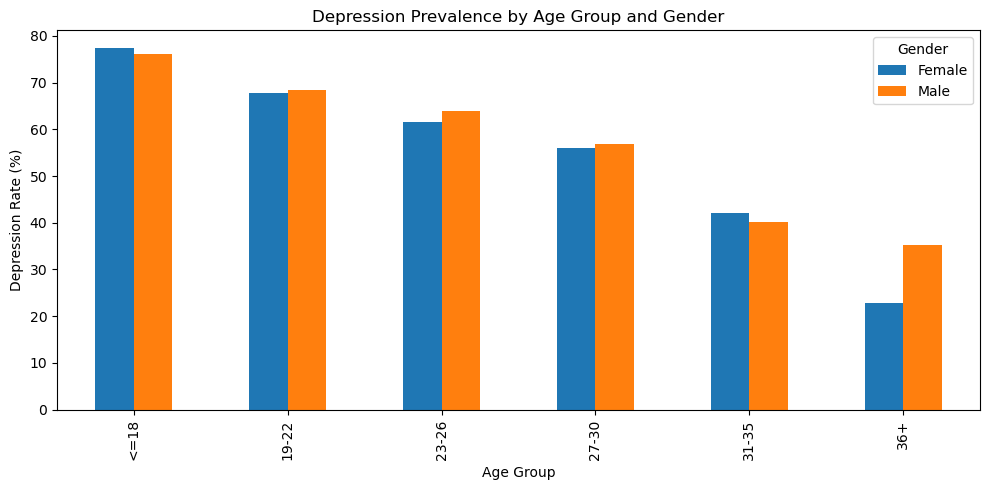

In [99]:
# Detailed visualization set for depression and mental-health patterns

# 1) Depression prevalence by Age Group and Gender
age_gender_rate = (
    df.groupby(["Age Group", "Gender"])["Depression"]
    .mean()
    .mul(100)
    .unstack(fill_value=0)
    .sort_index()
)

ax = age_gender_rate.plot(kind="bar", figsize=(10, 5))
ax.set_title("Depression Prevalence by Age Group and Gender")
ax.set_ylabel("Depression Rate (%)")
ax.set_xlabel("Age Group")
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

C:\Users\Sanjay M\AppData\Local\Temp\ipykernel_26708\767348815.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_rate = drep_df.groupby(risk_bins)["Depression"].mean().mul(100)


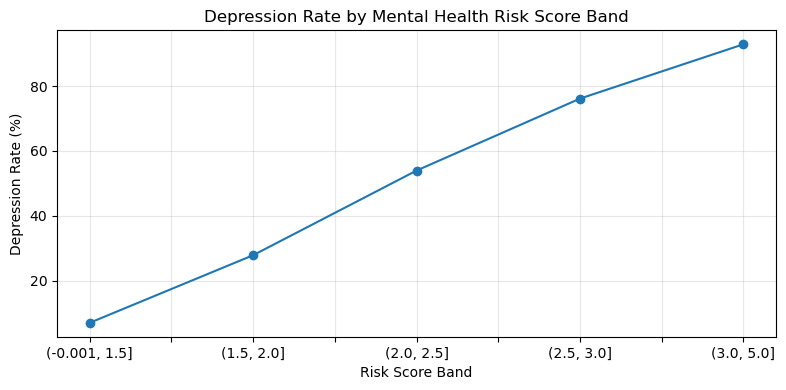

In [100]:
# 2) Depression rate across Mental Health Risk Score bands
risk_bins = pd.cut(
    drep_df["Mental Health Risk Score"],
    bins=[0, 1.5, 2.0, 2.5, 3.0, 5.0],
    include_lowest=True
)
risk_rate = drep_df.groupby(risk_bins)["Depression"].mean().mul(100)

ax = risk_rate.plot(marker="o", figsize=(8, 4))
ax.set_title("Depression Rate by Mental Health Risk Score Band")
ax.set_ylabel("Depression Rate (%)")
ax.set_xlabel("Risk Score Band")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

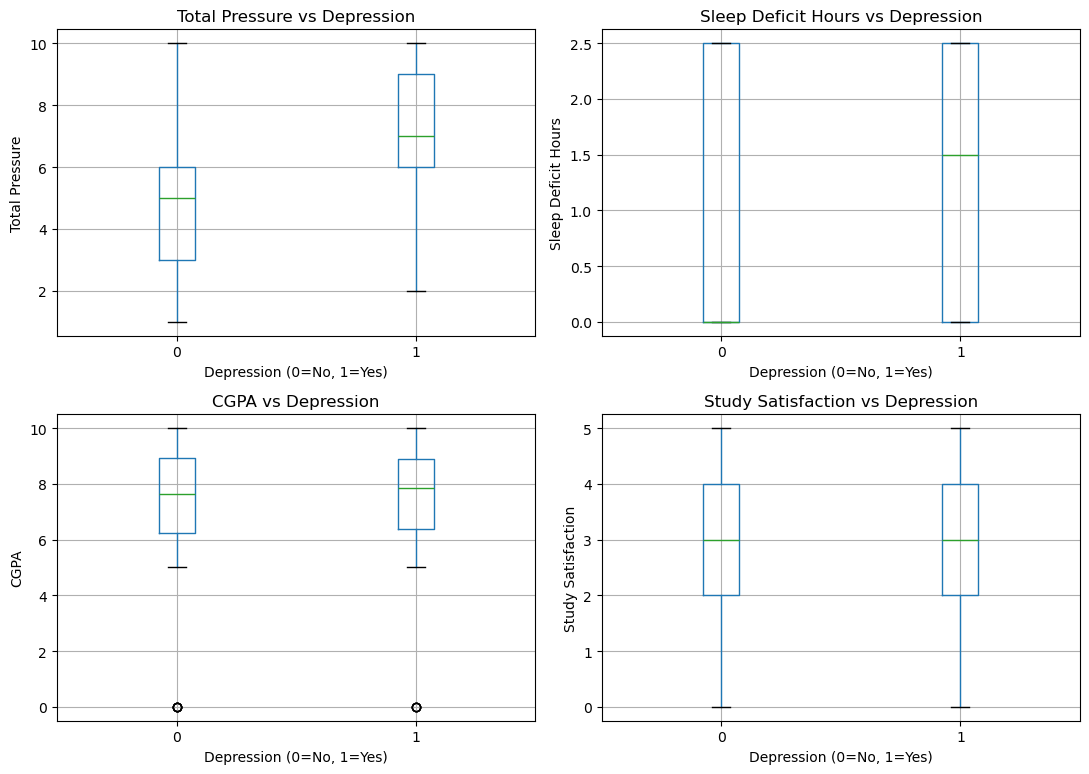

In [101]:
# 3) Key numeric factors by depression status (boxplots)
features = ["Total Pressure", "Sleep Deficit Hours", "CGPA", "Study Satisfaction"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, col_name in enumerate(features):
    drep_df.boxplot(column=col_name, by="Depression", ax=axes[i])
    axes[i].set_title(f"{col_name} vs Depression")
    axes[i].set_xlabel("Depression (0=No, 1=Yes)")
    axes[i].set_ylabel(col_name)

plt.suptitle("")
plt.tight_layout()
plt.show()

C:\Users\Sanjay M\AppData\Local\Temp\ipykernel_26708\882962414.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(
C:\Users\Sanjay M\AppData\Local\Temp\ipykernel_26708\882962414.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(
C:\Users\Sanjay M\AppData\Local\Temp\ipykernel_26708\882962414.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(
C:\Users\Sanjay M\AppData\Local\Temp\ipykernel_26708\882962414.py:20: FutureWarning: The default value of obs

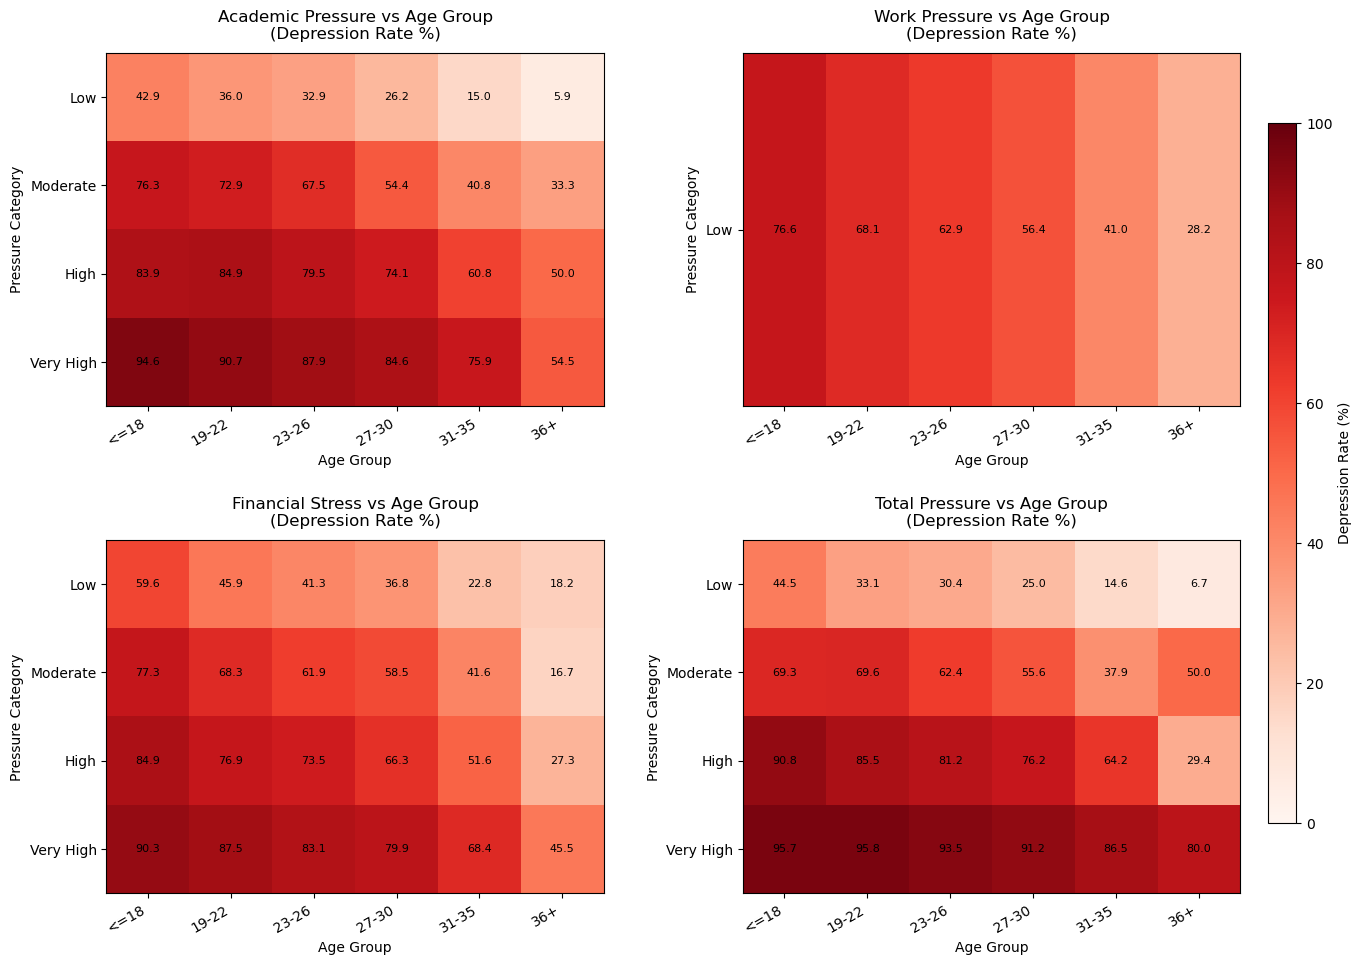

In [ ]:
# 4) Create pressure categories from Total Pressure using quartiles + include Age Group
pressure_cols = ["Academic Pressure", "Work Pressure", "Financial Stress", "Total Pressure"]
age_order = list(drep_df["Age Group"].cat.categories)
base_labels = ["Low", "Moderate", "High", "Very High"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, pressure_cols):
    tmp = drep_df[[col, "Age Group", "Depression"]].dropna().copy()
    n_unique = tmp[col].nunique()

    if n_unique <= 1:
        # Constant column -> single category
        tmp["Pressure_Category"] = "Low"
        labels = ["Low"]
    else:
        qcat = pd.qcut(tmp[col], q=min(4, n_unique), duplicates="drop")
        n_bins = len(qcat.cat.categories)
        labels = base_labels[:n_bins]
        tmp["Pressure_Category"] = pd.qcut(
            tmp[col], q=n_bins, labels=labels, duplicates="drop"
        )

    heat = (
        tmp.pivot_table(
            index="Pressure_Category",
            columns="Age Group",
            values="Depression",
            aggfunc="mean"
        )
        .reindex(index=labels, columns=age_order)
        .mul(100)
    )

    im = ax.imshow(heat.values, cmap="Reds", aspect="auto", vmin=0, vmax=100)
    ax.set_title(f"{col} vs Age Group\n(Depression Rate %)", pad=10)
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Pressure Category")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8, color="black")

fig.subplots_adjust(left=0.07, right=0.88, top=0.92, bottom=0.08, wspace=0.28, hspace=0.38)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cax, label="Depression Rate (%)")

plt.show()


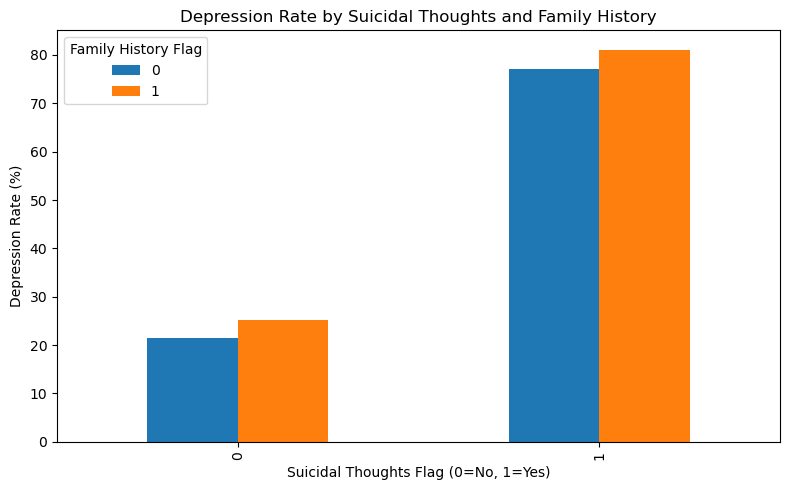

In [102]:
# 5) Combined impact of Suicidal Thoughts + Family History
combo_rate = (
    drep_df.groupby(["Suicidal Thoughts Flag", "Family History Flag"])["Depression"]
    .mean()
    .mul(100)
    .unstack(fill_value=0)
)

ax = combo_rate.plot(kind="bar", figsize=(8, 5))
ax.set_title("Depression Rate by Suicidal Thoughts and Family History")
ax.set_xlabel("Suicidal Thoughts Flag (0=No, 1=Yes)")
ax.set_ylabel("Depression Rate (%)")
ax.legend(title="Family History Flag")
plt.tight_layout()
plt.show()

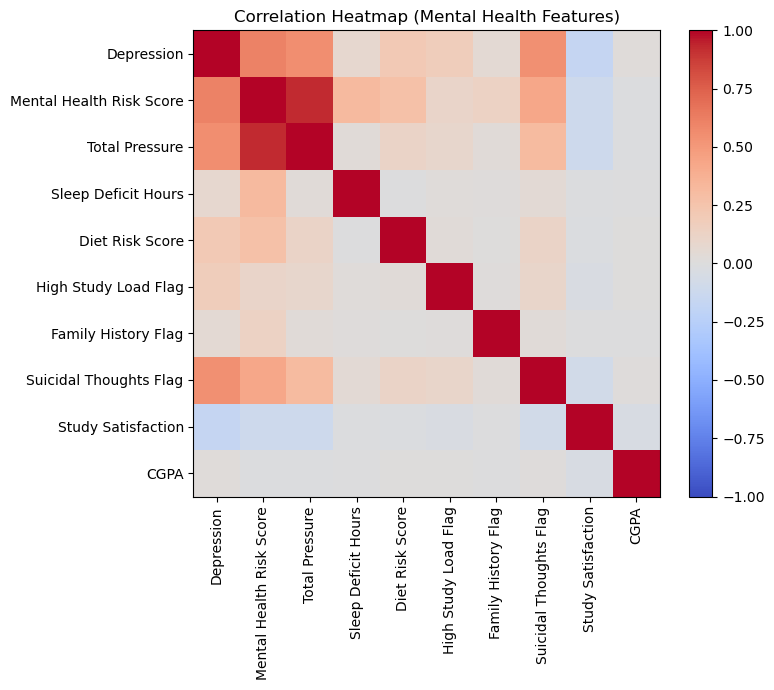

In [103]:
# 6) Correlation heatmap for numeric mental-health features
corr_cols = [
    "Depression", "Mental Health Risk Score", "Total Pressure",
    "Sleep Deficit Hours", "Diet Risk Score", "High Study Load Flag",
    "Family History Flag", "Suicidal Thoughts Flag", "Study Satisfaction", "CGPA"
]
corr = drep_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticklabels(corr_cols)
ax.set_title("Correlation Heatmap (Mental Health Features)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()